# Capstone Project 1
## Working with NumPy Matrices (Multidimensional Data)

**Dataset:** NHANES Adult Body Measurements (2020)

This report analyses multidimensional anthropometric data of adult males and females using NumPy, Matplotlib, and SciPy. The notebook is structured as a formal analytical report with explanations and interpretations for each step.


## 1. Import Required Libraries
**Purpose**

The purpose of this step is to download the male and female NHANES datasets that contain body measurements such as weight, height, and waist size. These datasets will be used for analysis and comparison in the later steps of the project.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import seaborn as sns



**Discussion**

The required data files were successfully obtained. These files provide real-world information about body measurements of adult males and females, which will be used for calculations, visualizations, and statistical analysis throughout the project.

## 2. Load NHANES Datasets as NumPy Matrices
**Purpose**

The purpose of this step is to import the male and female NHANES datasets into NumPy matrices so that the data can be processed and analyzed using Python. Loading the data correctly is a crucial first step because all further analysis depends on it. By reading the datasets into matrices, we can easily access different body measurements such as weight, height, arm length, and waist circumference. This step also helps us confirm the size and structure of the data, ensuring that it is ready for statistical analysis and visualization in the next stages.

In [2]:
male = np.genfromtxt("nhanes_adult_male_bmx_2020.csv", delimiter=",", skip_header=1)
female = np.genfromtxt("nhanes_adult_female_bmx_2020.csv", delimiter=",", skip_header=1)

print("\n" + "="*50)
print("        DATASET INFORMATION")
print("="*50)

print("\nMale Dataset Shape   :", male.shape)
print("Female Dataset Shape :", female.shape)

print("\nNumber of Features (Columns):", male.shape[1])

print("\nColumn Meaning:")
print("1. Weight (kg)")
print("2. Height (cm)")
print("3. Upper Arm Length (cm)")
print("4. Upper Leg Length (cm)")
print("5. Arm Circumference (cm)")
print("6. Hip Circumference (cm)")
print("7. Waist Circumference (cm)")

print("\n" + "="*50)
print("SAMPLE DATA (First 5 rows - Male)")
print("="*50)
print(male[:5])

print("\n" + "="*50)
print("SAMPLE DATA (First 5 rows - Female)")
print("="*50)
print(female[:5])



        DATASET INFORMATION

Male Dataset Shape   : (4082, 7)
Female Dataset Shape : (4222, 7)

Number of Features (Columns): 7

Column Meaning:
1. Weight (kg)
2. Height (cm)
3. Upper Arm Length (cm)
4. Upper Leg Length (cm)
5. Arm Circumference (cm)
6. Hip Circumference (cm)
7. Waist Circumference (cm)

SAMPLE DATA (First 5 rows - Male)
[[  nan   nan   nan   nan   nan   nan   nan]
 [ 98.8 182.3  42.   40.1  38.2 108.2 120.4]
 [ 74.3 184.2  41.1  41.   30.2  94.5  86.8]
 [103.7 185.3  47.   44.   32.  107.8 109.6]
 [ 86.  167.8  39.5  38.4  29.  106.4 108.3]]

SAMPLE DATA (First 5 rows - Female)
[[  nan   nan   nan   nan   nan   nan   nan]
 [ 97.1 160.2  34.7  40.8  35.8 126.1 117.9]
 [ 91.1 152.7  33.5  33.   38.5 125.5 103.1]
 [ 73.  161.2  37.4  38.   31.8 106.2  92. ]
 [ 61.7 157.4  38.   34.7  29.  101.   90.5]]


**Discussion**

The datasets were successfully loaded. The male dataset contains measurements of adult males, and the female dataset contains measurements of adult females. Each row represents one person, and each column represents a body measurement such as weight, height, arm length, and waist size. This confirms that the data is ready for further analysis.

## 3. Histograms of Female and Male Weights
**Purpose**

The aim of this step is to visually understand how body weights are distributed among males and females. Histograms help us see patterns such as whether most people fall within a certain weight range or if there are many extreme values. By plotting separate histograms for males and females using the same x-axis scale, we can easily compare the two groups. This visualization helps identify trends, such as which group generally has higher weights and how spread out the weights are.

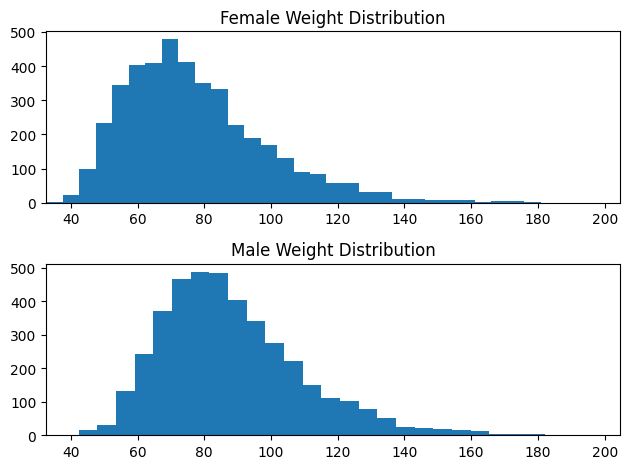

In [3]:

female_weights = female[:, 0]
male_weights = male[:, 0]

xmin = min(np.nanmin(female_weights), np.nanmin(male_weights))
xmax = max(np.nanmax(female_weights), np.nanmax(male_weights))

plt.subplot(2, 1, 1)
plt.hist(female_weights, bins=30)
plt.xlim(xmin, xmax)
plt.title("Female Weight Distribution")

plt.subplot(2, 1, 2)
plt.hist(male_weights, bins=30)
plt.xlim(xmin, xmax)
plt.title("Male Weight Distribution")

plt.tight_layout()
plt.show()


**Discussion**

The histograms show that male weights are generally higher than female weights. Both distributions appear slightly right-skewed, meaning there are some individuals with very high weights. Using the same x-axis range makes comparison easier and clearer.


## 4. Box-and-Whisker Plot of Weights
**Purpose**

The purpose of this step is to compare male and female weight data using a box-and-whisker plot. Unlike histograms, boxplots clearly show the median, spread, and possible outliers in the data. This allows us to quickly understand differences in central tendency and variation between the two groups. It also helps identify extreme values that may affect the overall analysis.

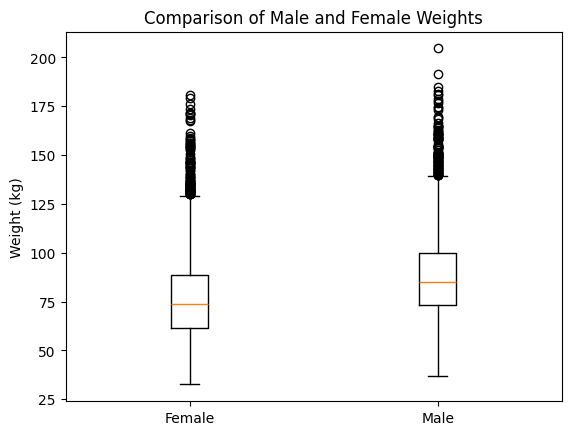

In [4]:

female_weights = female[:, 0]
male_weights = male[:, 0]

# Remove NaN values
female_weights = female_weights[~np.isnan(female_weights)]
male_weights = male_weights[~np.isnan(male_weights)]

plt.boxplot([female_weights, male_weights], tick_labels=["Female", "Male"])
plt.ylabel("Weight (kg)")
plt.title("Comparison of Male and Female Weights")
plt.show()

**Discussion:**  

The boxplot shows that males tend to have a higher median weight than females. The spread of male weights is also slightly larger, indicating more variation. Some outliers are visible, which represent individuals with unusually high or low weight.


## 5. Numerical Aggregates of Weights
**Purpose**

In this step, we calculate key statistical measures such as mean, median, standard deviation, skewness, and kurtosis. These values help us understand the overall shape and spread of the weight distributions. Instead of relying only on graphs, numerical statistics give precise information about the central value, variability, and distribution pattern of the data. This helps in comparing male and female weight characteristics more accurately.

In [5]:

def describe(data, name):
    print(f"\n{name} Weight Statistics")
    print("-" * 30)
    print(f"Mean     : {np.mean(data):.2f}")
    print(f"Median   : {np.median(data):.2f}")
    print(f"Std Dev  : {np.std(data):.2f}")
    print(f"Skewness : {stats.skew(data):.2f}")
    print(f"Kurtosis : {stats.kurtosis(data):.2f}")

describe(female_weights, "Female")
describe(male_weights, "Male")



Female Weight Statistics
------------------------------
Mean     : 77.40
Median   : 73.60
Std Dev  : 21.54
Skewness : 1.03
Kurtosis : 1.40

Male Weight Statistics
------------------------------
Mean     : 88.36
Median   : 85.00
Std Dev  : 21.42
Skewness : 0.98
Kurtosis : 1.47


**Discussion:** 
 
The average weight of males is higher than females. The standard deviation is also slightly higher for males, showing more variation in their weights. Both distributions show positive skewness, indicating that some individuals have higher-than-average weights.


## 6. Add BMI Column to Female Dataset

**Purpose**

The purpose of this step is to calculate Body Mass Index (BMI) for each female participant using their weight and height measurements. BMI is an important health indicator that helps classify individuals as underweight, normal, overweight, or obese. By adding BMI as a new column to the dataset, we enrich the data and make it possible to study health-related patterns in later steps. This also allows us to connect body measurements with health risk indicators.

In [6]:
# Convert height to meters
female_height_m = female[:,1] / 100

# Remove rows where weight OR height is missing
mask = (~np.isnan(female[:,0])) & (~np.isnan(female[:,1]))

female_weights_clean = female[:,0][mask]
female_height_clean = female_height_m[mask]

# Calculate BMI
female_bmi = female_weights_clean / (female_height_clean ** 2)

# Combine new dataset
female_with_bmi = np.column_stack((
    female_weights_clean,
    female_height_clean,
    female_bmi
))

print("New Female Dataset Shape (Weight, Height, BMI):", female_with_bmi.shape)

# BMI Categories
underweight = np.sum(female_bmi < 18.5)
normal = np.sum((female_bmi >= 18.5) & (female_bmi < 25))
overweight = np.sum((female_bmi >= 25) & (female_bmi < 30))
obese = np.sum(female_bmi >= 30)

print("\nBMI Category Distribution")
print("--------------------------")
print("Underweight :", underweight)
print("Normal      :", normal)
print("Overweight  :", overweight)
print("Obese       :", obese)

New Female Dataset Shape (Weight, Height, BMI): (4221, 3)

BMI Category Distribution
--------------------------
Underweight : 84
Normal      : 1094
Overweight  : 1176
Obese       : 1867


**Discussion:**
  
BMI helps measure body fat based on height and weight. After calculating BMI, we can better understand health risk levels in the dataset. This new column will be used for further analysis and comparison.


## 7. Standardise Female Dataset (Z-Scores)
**Purpose**

In this step, we standardize all body measurement values using z-scores so that each column has a mean of zero and a standard deviation of one. This is important because different measurements are recorded in different units and ranges. For example, height is in centimeters, while weight is in kilograms. Standardization puts all variables on the same scale, making it easier to compare them and perform correlation analysis in the next steps.

In [7]:
female_clean = female[~np.isnan(female).any(axis=1)]

zfemale = (female_clean - np.mean(female_clean, axis=0)) / np.std(female_clean, axis=0)

print("Standardized Dataset Shape:", zfemale.shape)

print("\nFirst 5 Rows of Standardized Data:")
print(zfemale[:5])

print("\nColumn-wise Mean (should be close to 0):")
print(np.mean(zfemale, axis=0))

print("\nColumn-wise Std Dev (should be close to 1):")
print(np.std(zfemale, axis=0))


Standardized Dataset Shape: (4221, 7)

First 5 Rows of Standardized Data:
[[ 0.91429508  0.00895038 -0.56739463  1.13298804  0.55084546  1.08316157
   1.11578462]
 [ 0.63577599 -1.05306843 -1.07893145 -1.29349161  1.03221804  1.04475528
   0.265089  ]
 [-0.2044233   0.15055289  0.5835632   0.26194406 -0.1622991  -0.19064688
  -0.37293272]
 [-0.7289676  -0.38753664  0.83933161 -0.76464348 -0.66150029 -0.52350135
  -0.45915188]
 [-1.02141265 -0.78402366 -0.6100227  -0.98240447 -0.78630059 -1.06759039
  -1.45354609]]

Column-wise Mean (should be close to 0):
[ 6.32035423e-15  9.94282179e-15 -7.46421798e-14 -1.26368683e-14
  1.28650151e-15 -5.79501700e-15  6.52264575e-15]

Column-wise Std Dev (should be close to 1):
[1. 1. 1. 1. 1. 1. 1.]


**Discussion:** 
 
After standardization, each column has a mean close to 0 and a standard deviation close to 1. This makes it easier to compare different body measurements fairly, even though they were originally in different units.


## 8. Scatterplot Matrix and Correlation Analysis
**Purpose**

The goal of this step is to study how different body measurements are related to each other. By creating a scatterplot matrix, we can visually examine relationships between variables such as weight, height, waist, hip, and BMI. Additionally, calculating Pearson and Spearman correlation coefficients helps us measure how strongly these variables are connected. This step helps identify which measurements influence BMI the most.

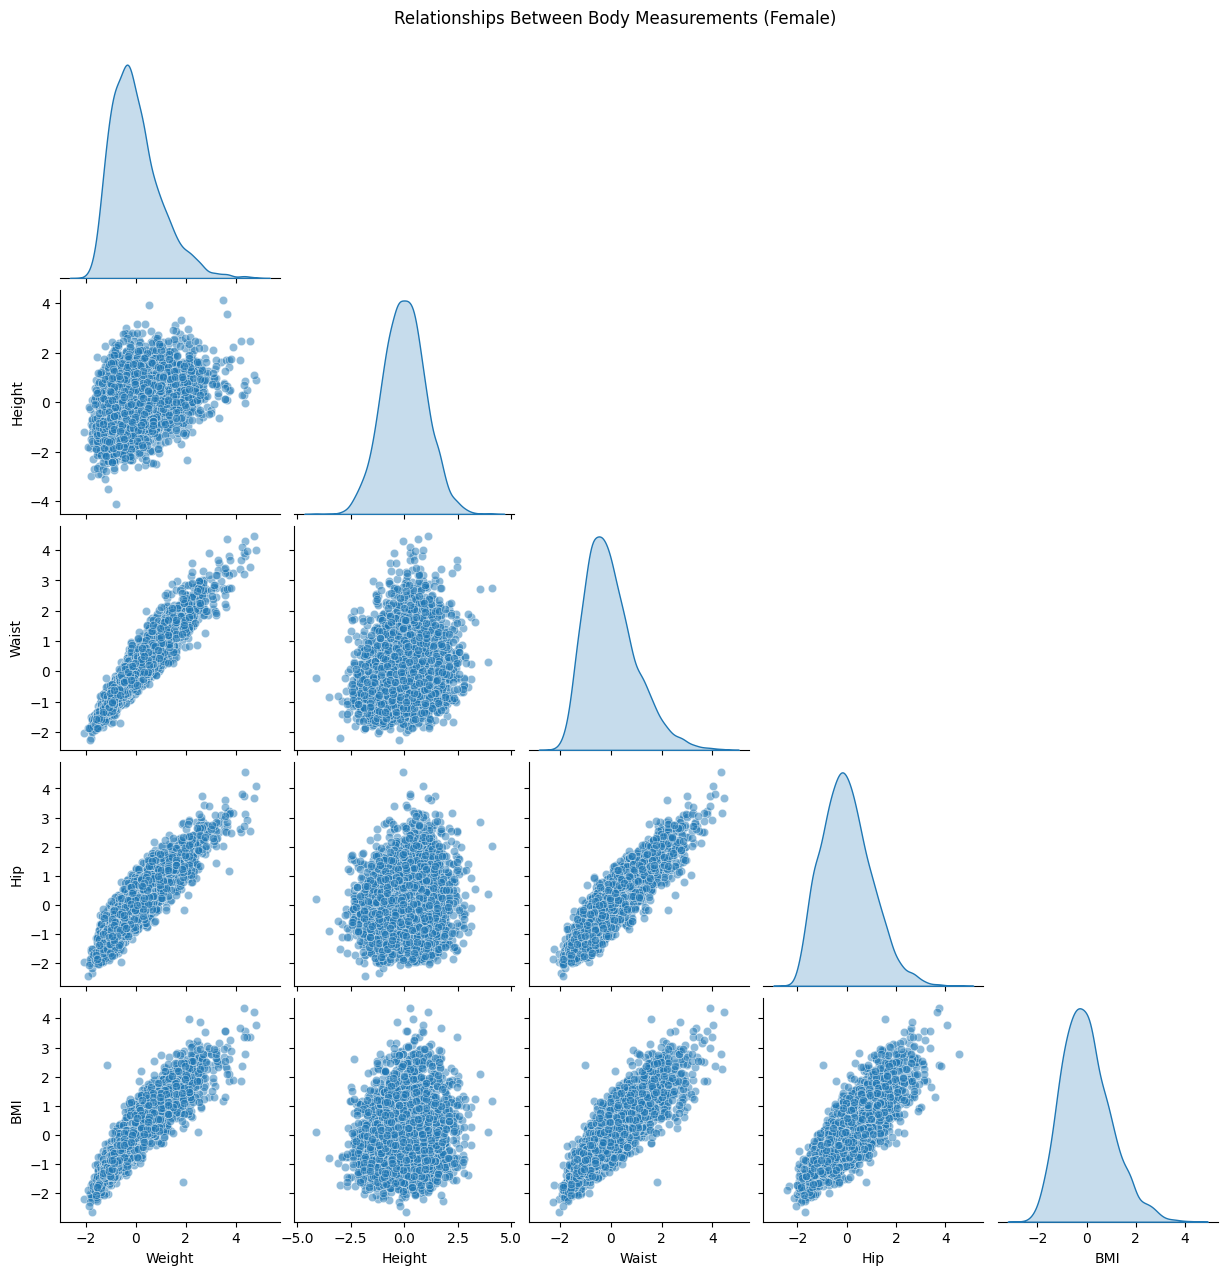

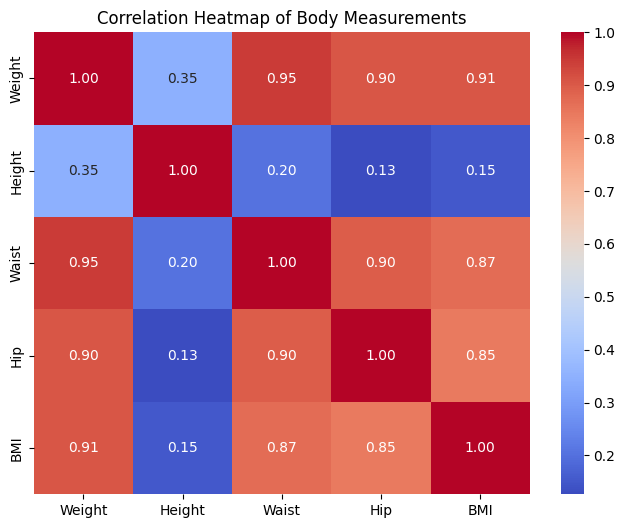

In [8]:
data_selected = pd.DataFrame(
    zfemale[:, [0,1,5,6,4]],
    columns=["Weight", "Height", "Waist", "Hip", "BMI"]
)

sns.pairplot(
    data_selected,
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha':0.5}
)

plt.suptitle("Relationships Between Body Measurements (Female)", y=1.02)
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(
    data_selected.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Body Measurements")
plt.show()

**Discussion:**  

The scatter plots show strong relationships between weight, waist size, hip size, and BMI. Height has a weaker relationship with BMI. Pearson and Spearman correlations confirm that these measurements are closely related.


## 9. Waist-to-Height and Waist-to-Hip Ratios
**Purpose**

The purpose of this step is to calculate two important health indicators: Waist-to-Height Ratio (WHtR) and Waist-to-Hip Ratio (WHR). These ratios provide insight into fat distribution in the body, especially around the abdominal area. Unlike BMI, which measures overall body mass, these ratios help identify central obesity, which is more closely linked to serious health risks such as heart disease and diabetes.

In [9]:
female_whtr = female[:, 6] / female[:, 1]   
female_whr  = female[:, 6] / female[:, 5]   

male_whtr = male[:, 6] / male[:, 1]
male_whr  = male[:, 6] / male[:, 5]

female_whtr = female_whtr[~np.isnan(female_whtr)]
female_whr  = female_whr[~np.isnan(female_whr)]
male_whtr   = male_whtr[~np.isnan(male_whtr)]
male_whr    = male_whr[~np.isnan(male_whr)]

print("\n" + "="*50)
print("   WAIST-BASED HEALTH RATIO ANALYSIS")
print("="*50)

print("\nFemale Statistics:")
print("Average Waist-to-Height Ratio :", round(np.mean(female_whtr), 3))
print("Average Waist-to-Hip Ratio    :", round(np.mean(female_whr), 3))

print("\nMale Statistics:")
print("Average Waist-to-Height Ratio :", round(np.mean(male_whtr), 3))
print("Average Waist-to-Hip Ratio    :", round(np.mean(male_whr), 3))



   WAIST-BASED HEALTH RATIO ANALYSIS

Female Statistics:
Average Waist-to-Height Ratio : 0.616
Average Waist-to-Hip Ratio    : 0.9

Male Statistics:
Average Waist-to-Height Ratio : 0.586
Average Waist-to-Hip Ratio    : 0.971


**Discussion**

These ratios give a better idea of abdominal fat and health risks. In general, males tend to have slightly higher waist-based ratios, indicating more central fat concentration.

## 10. Boxplot of Waist-Based Ratios
**Purpose**

In this step, we visually compare the waist-based ratios for males and females using boxplots. This allows us to observe differences in fat distribution between the two groups. The boxplot highlights median values, variability, and outliers, helping us understand how health risk indicators vary across genders.

Female dataset new shape: (4222, 9)
Male dataset new shape: (4082, 9)

New columns added:
Column 8 → Waist-to-Height Ratio
Column 9 → Waist-to-Hip Ratio


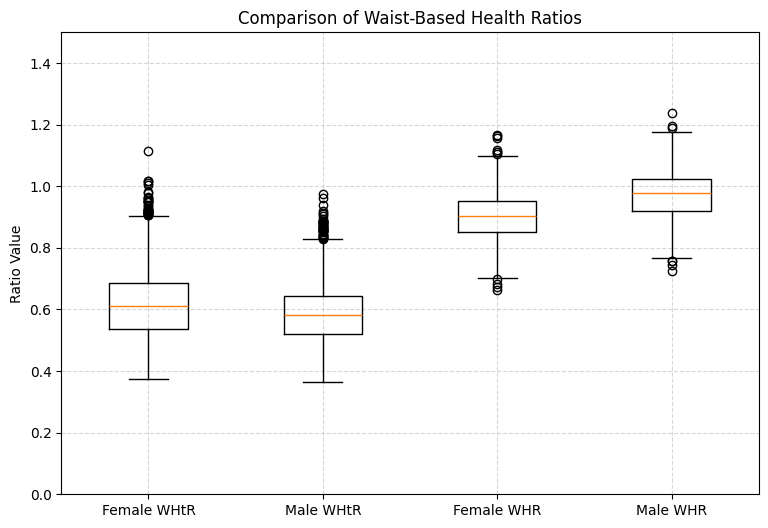

In [10]:
female_whtr = female[:, 6] / female[:, 1]   
female_whr  = female[:, 6] / female[:, 5]   
male_whtr = male[:, 6] / male[:, 1]
male_whr  = male[:, 6] / male[:, 5]

female = np.column_stack((female, female_whtr, female_whr))
male   = np.column_stack((male, male_whtr, male_whr))

print("Female dataset new shape:", female.shape)
print("Male dataset new shape:", male.shape)

print("\nNew columns added:")
print("Column 8 → Waist-to-Height Ratio")
print("Column 9 → Waist-to-Hip Ratio")

female_whtr_clean = female_whtr[~np.isnan(female_whtr)]
female_whr_clean  = female_whr[~np.isnan(female_whr)]
male_whtr_clean   = male_whtr[~np.isnan(male_whtr)]
male_whr_clean    = male_whr[~np.isnan(male_whr)]

ratio_data = [
    female_whtr_clean,
    male_whtr_clean,
    female_whr_clean,
    male_whr_clean
]

labels = [
    "Female WHtR",
    "Male WHtR",
    "Female WHR",
    "Male WHR"
]

import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

plt.boxplot(ratio_data, tick_labels=labels)

plt.title("Comparison of Waist-Based Health Ratios")
plt.ylabel("Ratio Value")
plt.ylim(0, 1.5)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

**Discussion:**  

The boxplot shows how these ratios differ between males and females. Males usually show higher waist-to-hip ratios, which may indicate higher abdominal fat levels. This helps in understanding health risk patterns.


## 11. Advantages and Disadvantages of Health Indices
**Purpose**

The aim of this step is to discuss the strengths and limitations of BMI, WHtR, and WHR as health indicators. This helps in understanding why multiple measures are needed to assess health risk. While BMI provides a general idea of body mass, waist-based ratios offer deeper insight into fat distribution and associated health risks.

**BMI (Body Mass Index)**

Advantages:
1. Simple and quick to calculate using only height and weight.
2. Widely used standard for classifying underweight, normal, overweight, and obesity.
3. Useful for large population studies.
4. Helps identify general weight-related health risks.

Disadvantages:
1. Does not measure body fat directly.
2. Cannot distinguish between muscle and fat (athletes may appear overweight).
3. Does not show fat distribution in the body.
4. May give misleading results for very muscular or very thin people.


**Waist-to-Height Ratio**

Advantages:
1. Shows fat stored around the stomach (central obesity).
2. Better predictor of heart disease and diabetes risk than BMI.
3. Works well for people of different heights.
4. Simple to calculate using waist and height.

Disadvantages:
1. Requires accurate waist measurement.
2. Not as commonly used as BMI in hospitals.
3. Cut-off values may vary across populations.

**Waist-to-Hip Ratio**

Advantages:
1. Measures fat distribution pattern in the body.
2. Identifies abdominal fat, which is more harmful.
3. Useful for predicting cardiovascular health risks.
4. Helps compare body shape differences.

Disadvantages:
1. Needs two measurements (waist and hip), which may cause errors.
2. Does not show total body fat level.
3. Less simple than BMI to calculate.


**Discussion**

BMI is simple and widely used but does not show fat distribution. WHtR and WHR provide better insights into abdominal fat, which is more strongly linked to health risks like heart disease and diabetes.

## 12. Extreme BMI Analysis
**Purpose**

The purpose of this step is to identify individuals with the lowest and highest BMI values and examine their standardized body measurements. This helps us understand how body size and fat distribution differ at the extreme ends of the BMI range. By comparing these individuals, we can clearly see which measurements have the strongest influence on BMI.

In [11]:
bmi_values = female[:, -1]   

sorted_indices = np.argsort(bmi_values)

lowest_5_idx = sorted_indices[:5]
highest_5_idx = sorted_indices[-5:]

lowest_5_people = zfemale[lowest_5_idx]
highest_5_people = zfemale[highest_5_idx]

print("Standardised measurements of 5 females with LOWEST BMI:\n")
print(lowest_5_people)

print("\nStandardised measurements of 5 females with HIGHEST BMI:\n")
print(highest_5_people)


Standardised measurements of 5 females with LOWEST BMI:

[[-1.25815389 -1.53451695 -2.14463315 -0.60909991 -1.08938703 -1.33003333
  -1.14315714]
 [ 1.16032029  0.56120016  1.99028945  2.40844529  1.12136111  1.01275004
   0.98932987]
 [ 0.20871337 -0.52913915 -0.26899816 -0.08025178  0.15861595 -0.05622488
   0.44327524]
 [-1.23958595 -0.21761363 -0.78053497 -0.29801278 -1.44595931 -1.13160086
  -1.66621999]
 [-0.40867064 -0.85482492 -0.86579111 -1.76012231 -0.05532741 -0.38267831
   0.20760956]]

Standardised measurements of 5 females with HIGHEST BMI:

[[ 0.36189887  0.39127715  0.41305093 -0.67131734  0.37255932 -0.06262593
   0.60421766]
 [ 2.78965702  0.88688592  2.97073501 -0.60909991  3.52822401  2.32496478
   2.33434863]
 [-0.63148592 -1.10970943 -1.63309633 -1.20016547 -0.89327227 -0.29306364
  -0.30970535]
 [-0.27405307  0.64616166  0.41305093  0.47970506  0.06947288 -0.48509507
  -0.57411074]
 [ 0.91429508  0.00895038 -0.56739463  1.13298804  0.55084546  1.08316157
   1.115

**Discussion:**  

People with the lowest BMI generally have lower weight, waist, and hip measurements. Those with the highest BMI show higher values in these measurements. This confirms that BMI is strongly influenced by body weight and fat distribution.


## 13. Conclusion

This project analyzed body measurements of adult males and females using NumPy and visualization tools. The results showed clear differences in weight distribution and strong relationships between weight, waist size, hip size, and BMI. Standardization and visualization helped in better understanding patterns in the data. Overall, this analysis provides useful insights into body composition and health indicators.
